In [1]:
import torch 
import torch.nn as nn
#turn off scientific notation
torch.set_printoptions(sci_mode=False)

import copy
import torch.nn.functional as F

import tqdm
from torch_linear_assignment import batch_linear_assignment, assignment_to_indices
from typing import List, Tuple, Dict, Any, Literal, Optional, Union

from src.utils.normalizer import Normalizer

from src.permute_compress import PermutedSparseWeight

/data/lliu/NoWAG/src/permute_compress.py:675: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../config/compress", config_name="permute")


In [2]:
# set CUDA_LAUNCH_BLOCKING=1
# to get the correct error message

! export CUDA_LAUNCH_BLOCKING=1

In [3]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_0/mlp.down_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )


hessian_diag = hessian_diag/torch.median(hessian_diag)

normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])

In [4]:
11008/256

43.0

In [5]:
hessian_diag

tensor([1.4324, 0.8063, 2.8333,  ..., 1.7838, 0.7072, 1.6622], device='cuda:7')

In [6]:
torch.all(torch.isfinite(hessian_diag))

tensor(True, device='cuda:7')

In [7]:
weight.shape[0]/32

128.0

In [ ]:
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

P = PermutedSparseWeight(original_weight=weight,
                            n_permutations_0=8,
                            n_permutations_1=8,
                            N=2,
                            M=4,
                            block_size=64,
                            initalize_method="Greedy",
                            importance_weight=hessian_diag
                            )
P.to(device)

l = [P.recon_loss(reduction="mean").item()]
print("initial loss", l[0])
optimizer = torch.optim.Adam(P.parameters(), lr=1e-4)
n_adam_steps = 10
n_permutation_to_change = 1
for i in range(100):

    # print(10*"==")


            
        #reinitalize a new optimizer
    for j in range(n_adam_steps):
        optimizer.zero_grad()
        loss = P.recon_loss(reduction="mean")
        loss.backward()
        optimizer.step()
        l.append(loss.item())
    if n_adam_steps > 0:
        print(f"loss after {n_adam_steps} steps = {loss.item()}")
        
    #randomly select a permutation to optimize
    with torch.no_grad():
        for j in range(n_permutation_to_change):
            prev_state_dict = copy.deepcopy(P.state_dict()) 
            #randomly select a dimension to optimize
            permutation_dim = 0 if torch.randint(0, 2, (1,)).item() == 0 else 1
            # permutation_dim = 1
            # print(f"Greedy optimizing permutation {permutation_dim}")

            prev_loss = P.recon_loss(reduction="mean")
            P.greedy_optimize_permutation(permutation_dim)
            new_loss = P.recon_loss(reduction="mean")
            # assert new_loss <= prev_loss + 1e-8, f"Loss should decrease but is {new_loss} > {prev_loss}"
            # print(f"prev_loss = {prev_loss.item()}, new_loss = {new_loss.item()}")
            if new_loss/prev_loss - 1 >  1e-3:
                print("Loss increased, reverting to previous state")
                P.load_state_dict(prev_state_dict)
                assert P.recon_loss() == prev_loss, f"Loss should be the same but is {P.recon_loss()} != {prev_loss}"
                # P.load_state_dict(prev_state_dict)
                # print("prev_loss", prev_loss.item())
                # print("new_loss", new_loss.item())
            else:
                l.append(new_loss.item())
            # break
            # break
            # assert new_loss <= prev_loss + 1e-8, f"Loss should decrease but is {new_loss} > {prev_loss}"
            # break
            # l.append(new_loss.item())
    print("loss", l[-1])
    # raise Exception("stop")

initial loss 0.06186404824256897
loss after 10 steps = 0.06184668838977814
loss 0.06171886995434761
loss after 10 steps = 0.061647456139326096
loss 0.06155719608068466
loss after 10 steps = 0.06149375066161156
loss 0.06145128235220909
loss after 10 steps = 0.061419494450092316
loss 0.0613546259701252
loss after 10 steps = 0.06130058690905571
loss 0.06129748001694679
loss after 10 steps = 0.06127740815281868
loss 0.06126474589109421
loss after 10 steps = 0.06122884526848793
loss 0.061218347400426865
loss after 10 steps = 0.06118422746658325
loss 0.06117667257785797
loss after 10 steps = 0.06115254387259483
loss 0.06114575266838074
loss after 10 steps = 0.06112716719508171
loss 0.06111440807580948
loss after 10 steps = 0.0610964372754097
loss 0.06109338626265526
loss after 10 steps = 0.06108291819691658
loss 0.06107684224843979
loss after 10 steps = 0.06105928122997284
loss 0.061054155230522156
loss after 10 steps = 0.06104264780879021
loss 0.06104167550802231
loss after 10 steps = 0.061

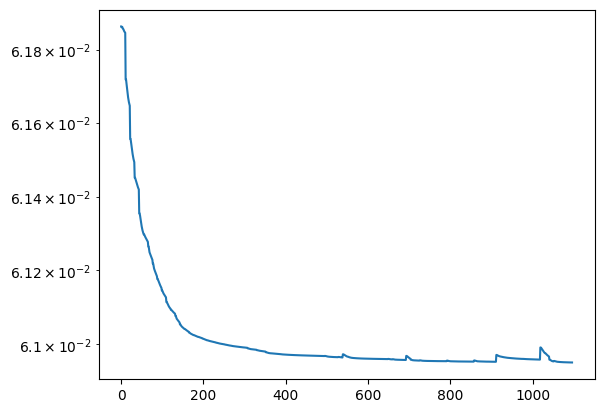

In [18]:
import matplotlib.pyplot as plt 
plt.plot(l)
plt.yscale("log")
# plt.xscale("log")

In [19]:
P()

tensor([[     0.0006,     -0.0149,      0.0087,  ...,     -0.0178,
             -0.0005,      0.0004],
        [     0.0006,     -0.0005,      0.0092,  ...,      0.0004,
              0.0020,      0.0325],
        [     0.0001,      0.0341,     -0.0001,  ...,     -0.0007,
              0.0006,      0.0169],
        ...,
        [    -0.0088,      0.0007,      0.0001,  ...,      0.0233,
             -0.0004,      0.0300],
        [    -0.0178,      0.0371,     -0.0004,  ...,     -0.0002,
              0.0011,     -0.0217],
        [     0.0122,     -0.0028,      0.0006,  ...,     -0.0006,
              0.0003,     -0.0302]], device='cuda:7', grad_fn=<ViewBackward0>)

In [20]:
P.original_weight

tensor([[ 0.0027, -0.0145,  0.0083,  ..., -0.0175, -0.0054,  0.0014],
        [ 0.0046, -0.0042,  0.0090,  ...,  0.0160, -0.0138,  0.0334],
        [ 0.0020,  0.0339, -0.0044,  ..., -0.0146,  0.0220,  0.0167],
        ...,
        [-0.0089, -0.0114,  0.0052,  ...,  0.0231, -0.0135,  0.0295],
        [-0.0177,  0.0374,  0.0090,  ..., -0.0069, -0.0122, -0.0219],
        [ 0.0120, -0.0013, -0.0079,  ..., -0.0003, -0.0030, -0.0302]],
       device='cuda:7')

In [21]:
P.permutations_0    

tensor([[   0,    1,    2,  ..., 4093, 4094, 4095],
        [  58,   56,   17,  ..., 4082, 4078, 4062],
        [  31,   30,   59,  ..., 4045, 4048, 4072],
        [  35,   53,   15,  ..., 4055, 4049, 4085]], device='cuda:7')

In [22]:
P.c_1

Parameter containing:
tensor([[ 0.9950,  0.9902,  0.9974,  ...,  0.9965,  0.9945,  0.9916],
        [-0.0317, -0.0322, -0.0114,  ...,  0.0524, -0.0481, -0.0516],
        [ 0.0243,  0.0478,  0.0190,  ...,  0.0462, -0.0478, -0.0421],
        [ 0.0322, -0.0542, -0.0168,  ..., -0.0313, -0.0465, -0.0202]],
       device='cuda:7', requires_grad=True)

In [16]:
import torch

M = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [1, 2, 3]])

M = torch.stack([M, M], dim=0)

v = torch.tensor([1, 2, 3])

mask = (M == v.unsqueeze(0).unsqueeze(2)).all(dim=1)
print(mask)  # Output: tensor([ True, False,  True])

tensor([[False, False, False],
        [False, False, False]])
